# Sistemas LTI: Tests de controlabilidad

**Nota:** algunas integraciones pueden tardar un poco, paciencia.

In [43]:
import numpy as np
import control as ct
from scipy.linalg import expm
from scipy.integrate import quad_vec, solve_ivp
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

Vamos a llevar a cabo los distintos tests de controlabilidad sugeridos en la teoría. Vamos a crear dos sistemas, uno controlable y otro no controlable:

**Controlable:**
$$A_c =\begin{pmatrix}1&2&0 \\ -2&3&0\\ 1&0&-2\end{pmatrix}, \quad B = \begin{pmatrix}1& 2\\ 1&0\\ 0&0\end{pmatrix}$$

**No controlable:**
$$A_i =\begin{pmatrix}1&2&0 \\ -2&3&0\\ 0&0&-2\end{pmatrix}, \quad B = \begin{pmatrix}1& 2\\ 1&0\\ 0&0\end{pmatrix}$$

In [44]:
Ac = np.array([[1, 2, 0], [-2, 3, 0], [1, 0, -2]])
B  = np.array([[1, 2], [1, 0], [0, 0]])   # es comun a los dos sistemas
Ai = np.array([[1, 2, 0], [-2, 3, 0], [0, 0, -2]])

## Matriz de controlabilidad

Para construir la matriz de controlabilidad, se puede usar directamente `control.ctrb` (equivalente a `ctrb` de MATLAB).

In [45]:
Cc = ct.ctrb(Ac, B)
Ci = ct.ctrb(Ai, B)
print('Cc =\n', Cc)
print('Ci =\n', Ci)

Cc =
 [[  1.   2.   3.   2.   5.  -6.]
 [  1.   0.   1.  -4.  -3. -16.]
 [  0.   0.   1.   2.   1.  -2.]]
Ci =
 [[  1.   2.   3.   2.   5.  -6.]
 [  1.   0.   1.  -4.  -3. -16.]
 [  0.   0.   0.   0.   0.   0.]]


Por supuesto, podríamos hacerlo empleando la definición,

$$\mathcal{C} = [B\ AB\ A^2B\ \cdots\ A^{n-1}B]$$

mientras el sistema sea pequeño.

In [46]:
cCc = np.hstack([B, Ac @ B, Ac @ Ac @ B])
cCc

array([[  1,   2,   3,   2,   5,  -6],
       [  1,   0,   1,  -4,  -3, -16],
       [  0,   0,   1,   2,   1,  -2]])

Sabemos que el sistema será controlable si $\mathcal{C}$ tiene rango igual a la dimensión del sistema.

In [47]:
rc = np.linalg.matrix_rank(Cc)
ri = np.linalg.matrix_rank(Ci)
print('rank(Cc) =', rc)
print('rank(Ci) =', ri)

rank(Cc) = 3
rank(Ci) = 2


Lo que confirma que el primer sistema es controlable y el segundo no.

## Test de autovectores

Un par $(A,B)$ es controlable si no existe ningún autovector de $A^T$ en el kernel de $B^T$.

Calculamos entonces los autovectores y autovalores de las matrices traspuestas de ambos sistemas.

> **Nota:** el orden de salida de `np.linalg.eig` es `(autovalores, autovectores)`, al revés que en MATLAB (`[V,D] = eig(A)` da primero los autovectores).

In [48]:
lc, avc = np.linalg.eig(Ac.T)   # lc: autovalores, avc: autovectores (columnas)
li, avi = np.linalg.eig(Ai.T)
print('autovalores Ac.T:', lc)
print('autovalores Ai.T:', li)

autovalores Ac.T: [ 2.+1.7321j  2.-1.7321j -2.+0.j    ]
autovalores Ai.T: [ 2.+1.7321j  2.-1.7321j -2.+0.j    ]


De aquí podemos aprender ya muchas cosas de ambos sistemas. Para empezar es bueno recordar que los autovalores de $A$ y $A^T$ son iguales.

Por tanto, podemos estudiar la estabilidad de nuestros sistemas examinando los autovalores obtenidos. En ambos casos, obtenemos autovalores con parte real positiva, así que ninguno de los dos sistemas es estable.

Veamos ahora la controlabilidad con el test de autovectores. Podemos multiplicar $B^T$ por las matrices de autovectores que hemos obtenido:

In [49]:
testc = B.T @ avc
testi = B.T @ avi
print('testc =\n', testc)
print('testi =\n', testi)

testc =
 [[ 0.3536-0.6124j  0.3536+0.6124j -0.1519+0.j    ]
 [ 1.4142+0.j      1.4142+0.j     -0.5064+0.j    ]]
testi =
 [[0.3536-0.6124j 0.3536+0.6124j 0.    +0.j    ]
 [1.4142+0.j     1.4142+0.j     0.    +0.j    ]]


Observamos que en el primer caso, todos los resultados son distintos de cero, por tanto no hay ningún autovector de $A_c^T$ en el kernel de $B^T$. Sin embargo el último autovector de $A_i^T$ da como resultado 0, por tanto dicho autovector está en el kernel de $B^T$ y el segundo sistema no es controlable, como ya sabíamos.

Ojo, este test hay que pasarlo con cuidado para los casos en que tenemos autovalores repetidos, que tenga autovectores asociados con una multiplicidad geométrica mayor que uno. Hay que comprobar que no existe ningún vector en el espacio expandido por dichos autovectores que esté en el kernel de $B$.

## Test de Lyapunov para controlabilidad

En este caso, debemos encontrar una solución $W\succ 0$ para la ecuación de Lyapunov:

$$AW+WA^T = -BB^T$$

Hay que recordar que esta ecuación solo se cumple en el caso de que $A$ sea una matriz de estabilidad (Hurwitz); ninguno de nuestros sistemas lo cumple, por lo que no debemos encontrar la solución deseada. Para comprobarlo, empleamos `control.lyap` (equivalente a `lyap` de MATLAB).

In [50]:
W = ct.lyap(Ac, B @ B.T)
lW = np.linalg.eigvals(W)
print('W =\n', W)
print('eig(W) =', lW)

W =
 [[-1.2857 -0.6071  0.0238]
 [-0.6071 -0.5714  0.6548]
 [ 0.0238  0.6548  0.0119]]
eig(W) = [-1.7118 -0.6307  0.4973]


La matriz obtenida $W$ no es definida positiva, el sistema no es estable y por eso no obtenemos solución adecuada para la ecuación de Lyapunov. Para comprobar que sí funciona para un sistema estable, vamos a definir una nueva matriz $A_e$,

$$A_e = \begin{pmatrix}-1 &-2& -1\\ 0&-1 &-1\\ 1&-2&-2\end{pmatrix}$$

In [51]:
Ae = np.array([[-1, 2, -1], [0, -1, -1], [1, -2, -2]])
lAe = np.linalg.eigvals(Ae)                       # estable
rank_ctrb_Ae = np.linalg.matrix_rank(ct.ctrb(Ae, B))  # controlable
print('eig(Ae) =', lAe)
print('rank(ctrb(Ae,B)) =', rank_ctrb_Ae)

eig(Ae) = [-3. +0.j    -0.5+0.866j -0.5-0.866j]
rank(ctrb(Ae,B)) = 3


Por tanto la matriz $A_e$ es una matriz de estabilidad y el par $(A_e,B)$ es controlable. Veamos qué dice ahora el test de Lyapunov,

In [52]:
W = ct.lyap(Ae, B @ B.T)
lp = np.linalg.eigvals(W)
print('W =\n', W)
print('eig(W) =', lp)

W =
 [[ 4.5     1.1923  0.3846]
 [ 1.1923  0.7564 -0.2564]
 [ 0.3846 -0.2564  0.4487]]
eig(W) = [4.8676 0.0656 0.7719]


Todos los autovalores son positivos, lo que implica que $W$ es definida positiva.

Podemos obtener también $W$ calculando el gramiano "infinito". Recordad que el gramiano "infinito" es la única solución al test de Lyapunov de estabilidad.

$$W = \int_0^\infty e^{A\tau}BB^Te^{A^T\tau}\,d\tau$$


In [53]:
def dgramr(t, A, B):
    """
    Integrando del gramiano de alcanzabilidad 'infinito' para el par (A, B).
    """
    return expm(A * t) @ B @ B.T @ expm(A.T * t)

Usamos `scipy.integrate.quad_vec`, que sirve para integrar funciones que devuelven un array (aquí, una matriz) en vez de un escalar, algo que la función `quad` normal de `scipy` no permite directamente.

In [54]:
W, err = quad_vec(lambda t: dgramr(t, Ae, B), 0, np.inf)
lW = np.linalg.eigvals(W)
print('W =\n', W)
print('eig(W) =', lW)

W =
 [[ 4.5     1.1923  0.3846]
 [ 1.1923  0.7564 -0.2564]
 [ 0.3846 -0.2564  0.4487]]
eig(W) = [4.8676 0.0656 0.7719]


Por supuesto, obtenemos el mismo resultado que empleando la función `lyap`.

## Estabilización por realimentación de estados

Volvamos a los dos sistemas del principio: el primero debería ser estabilizable por realimentación de estados, empleando la ecuación de Lyapunov. El segundo, no, ya que no es posible encontrar una matriz $W$ que cumpla con el test de Lyapunov para el sistema realimentado.

Sabemos que podemos estabilizar el sistema empleando un parámetro $\mu>0$. Para ello debemos encontrar una matriz $P\succ0$ de modo que satisfaga la ecuación de Lyapunov,

$$P(A-BK)+(A-BK)^TP=-2\mu P$$

Para ello, empezamos por resolver la ecuación de Lyapunov

$$(-\mu I-A)W+W(-\mu I -A)^T = -BB^T$$

Vamos a elegir, por ejemplo, $\mu=3$. Se debe elegir mayor que el menor autovalor de $A_c$ (parte real), tomado en valor absoluto; si no, el sistema no será estable y no habrá solución para la ecuación de Lyapunov definida positiva (puede no haber solución en absoluto).

In [55]:
mu = 3
W = ct.lyap(-mu*np.eye(3) - Ac, B @ B.T)
lW = np.linalg.eigvals(W)
print('W =\n', W)
print('eig(W) =', lW)

W =
 [[ 0.5357  0.1786 -0.087 ]
 [ 0.1786  0.1429 -0.0504]
 [-0.087  -0.0504  0.087 ]]
eig(W) = [0.6232 0.0868 0.0556]


Definida positiva por los pelos... Podemos probar con otros valores de  $\mu$, pero el ajuste es delicado 

Ahora tomamos $P = W^{-1}$ y la ganancia de nuestra realimentación será $K = \frac{1}{2}B^TP$.

In [56]:
P = np.linalg.inv(W)
K = B.T @ P / 2
K

array([[-0.2098,  4.6341,  2.4732],
       [ 3.2878, -3.7073,  1.1415]])

Podemos comprobar dónde quedan nuestros autovalores en lazo cerrado,

In [57]:
lAccl = np.linalg.eigvals(Ac - B @ K)
lAccl

array([-3.+3.0138j, -3.-3.0138j, -3.+0.j    ])

Todos con parte real menor o igual a $-\mu$.

Vamos a obtener los estados del sistema en función del tiempo para una condición inicial arbitraria. Para ello, creamos una función para el sistema realimentado, en la que hemos cambiado la entrada $u$ por la ganancia $K$.

In [58]:
def sistema_lineal(t, x, K, A, B):
    """Sistema lineal realimentado: u = -Kx  =>  xdot = (A - BK)x"""
    u = -K @ x
    return A @ x + B @ u

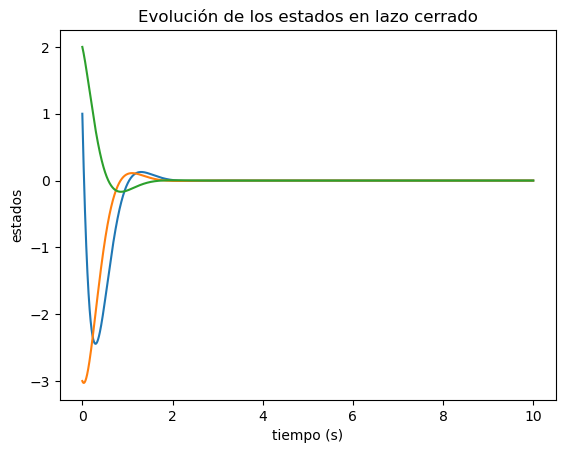

In [59]:
tf = 10
x0 = [1, -3, 2]

sol = solve_ivp(sistema_lineal, [0, tf], x0, args=(K, Ac, B), max_step=1e-3)

plt.figure(1)
plt.plot(sol.t, sol.y.T)
plt.xlabel('tiempo (s)')
plt.ylabel('estados')
plt.title('Evolución de los estados en lazo cerrado')
plt.show()

Podemos emplear, con idénticos resultados, los objetos de `control` para sistemas lineales. Creamos un sistema completo con `control.ss` (equivalente a `ss` de MATLAB). Pero, ojo, le damos ya la matriz en lazo cerrado (ojo a las dimensiones de $C$ y $D$: no sirven para nada en nuestro caso, pero deben ser coherentes con el tamaño del sistema).

In [60]:
sys = ct.ss(Ac - B @ K, B, np.eye(3), np.zeros((3, 2)))
sys

StateSpace(array([[-5.3659,  4.7805, -4.7561],
       [-1.7902, -1.6341, -2.4732],
       [ 1.    ,  0.    , -2.    ]]), array([[1., 2.],
       [1., 0.],
       [0., 0.]]), array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), array([[0., 0.],
       [0., 0.],
       [0., 0.]]))

Podemos ahora simular la respuesta del sistema para las mismas condiciones iniciales de antes, empleando `control.initial_response` (equivalente al comando `initial` de MATLAB).

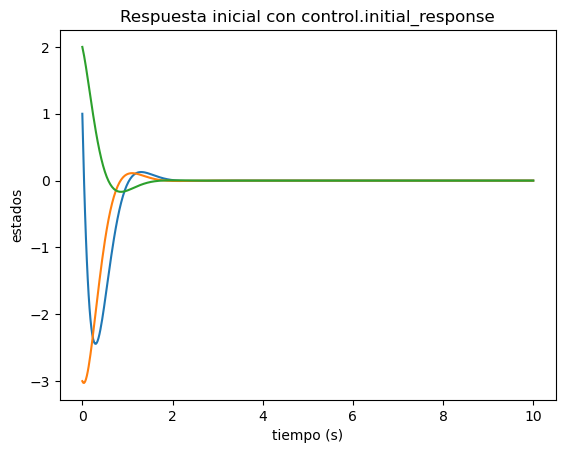

In [61]:
t_out, y_out = ct.initial_response(sys, T=np.linspace(0, tf, 500), X0=x0)

plt.figure(2)
plt.plot(t_out, y_out.T)
plt.xlabel('tiempo (s)')
plt.ylabel('estados')
plt.title('Respuesta inicial con control.initial_response')
plt.show()

Por último podemos emplear `control.place` (equivalente a `place` de MATLAB) para poner los autovalores del sistema $(A_c,\ B)$ donde nos dé la gana (recordad que `place` puede dar lugar a resultados mal condicionados y hay que manejarlo con cautela). Ojo: `place` no puede poner autovalores repetidos con multiplicidad mayor que el rango de $B$. Es decir, en nuestro caso podríamos por ejemplo poner autovalores $[-2,-2,-1]$, pero no $[-2,-2,-2]$ :(

Primero definimos un vector con los valores deseados.

In [62]:
lam = [-1, -2, -3]
K2 = ct.place(Ac, B, lam)
lAccl2 = np.linalg.eigvals(Ac - B @ K2)
print('K2 =\n', K2)
print('eig(Ac - B@K2) =', lAccl2)

K2 =
 [[-1.7183  4.9971  0.0103]
 [ 2.3606 -1.368  -0.4684]]
eig(Ac - B@K2) = [-3. -1. -2.]


En este caso `place` los ha colocado bastante bien.

Podemos volver a simular para ver cómo evolucionan los estados en el tiempo,

In [64]:
sol2 = solve_ivp(sistema_lineal, [0, tf], x0, args=(K2, Ac, B), max_step=1e-3)
#EL siguiente es un comando mágico de Jupyter Notebook para 
# mostrar gráficos en una ventana separada super chuli
%matplotlib qt
plt.figure(3)
plt.plot(sol2.t, sol2.y.T)
plt.xlabel('tiempo (s)')
plt.ylabel('estados')
plt.title('Evolución de los estados con K obtenida por place')
plt.show()

Como todos los autovalores son ahora reales, no se observa sobreoscilación en la evolución de los estados.